# ⚡ TSDynamics — the Grand Tour

**A single-notebook, hands-on tour of the [TSDynamics](https://github.com/El3ssar/TSDynamics)
library** — for the workshop at the *Max Planck Institute for the Physics of Complex Systems*.

You know nonlinear dynamics. In one sitting you'll learn to *do* it with this library, the way the
library wants to be used: integrate flows and maps, compose and style plots, reduce a flow to a
**2-D Poincaré map**, quantify chaos, **build your own system**, watch a **reaction–diffusion field**
self-organize on camera, and finally **solve a real analysis problem** from a single measured signal.

**How to use this notebook:** read a cell, run it (`Shift+Enter`), look at the result. Wherever you see
**▶ Try it**, change a value and re-run. Everything computes in seconds — except the Gray–Scott movie
(Part 6), which takes about a minute and is worth it.

*Approx. 75 minutes. There is also a full multi-notebook version on the
[`main` branch](https://github.com/El3ssar/tsdynamics-workshop).*

In [1]:
# Setup — installs the stack on Colab's first run (~40 s); a no-op locally.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "imageio-ffmpeg"], check=True)

try:  # embed figures inline
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts

# let matplotlib write .mp4 using the ffmpeg bundled with imageio-ffmpeg (so Part 6 works on Colab too)
try:
    import imageio_ffmpeg, matplotlib as mpl
    mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
except Exception:
    pass

print("tsdynamics", ts.__version__, "— ready.")

tsdynamics 5.3.1 — ready.


## 1 · Integrate, and meet the `viz` layer

The whole library follows one rhythm: **pick a system → `.integrate()` → get a `Trajectory` → plot it.**
The `Trajectory` knows how to draw itself — you rarely reach for raw matplotlib.

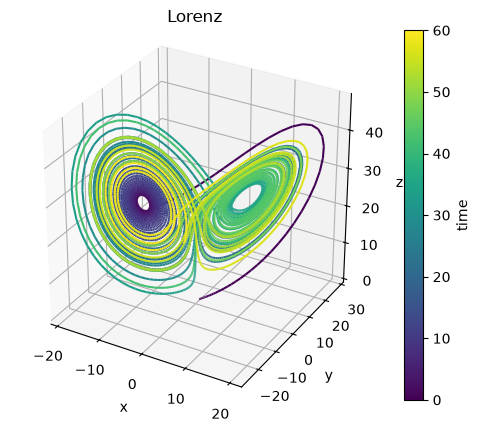

In [2]:
lorenz = ts.Lorenz().integrate(final_time=60.0, dt=0.01)
lorenz.plot(kind="phase_portrait_3d", color_by="time")     # the Trajectory renders itself

The data is right there: `lorenz.y` is the `(steps, 3)` state array, `lorenz.t` the times, and — since
Lorenz names its axes — `lorenz["x"]` is a single channel. Provenance (solver, `dt`, tolerances…) rides
along in `lorenz.meta`.

In [3]:
print("state array:", lorenz.y.shape, "| time:", lorenz.t.shape)
print("named channel lorenz['x']:", lorenz["x"][:3], "…")
print("solver used:", lorenz.meta["method"], "| backend:", lorenz.meta["backend"])

state array: (6001, 3) | time: (6001,)
named channel lorenz['x']: [0.44093475 0.49186428 0.55006894] …
solver used: rk45 | backend: interp


`ts.viz.plot(...)` is the figure-level front door: hand it several things and a `layout`, and it composes
them. It returns a `PlotSpec` you can **style fluently** (`.theme`, `.style`, `.recolor`) and **save** to
`.png` / `.pdf` / `.html`.

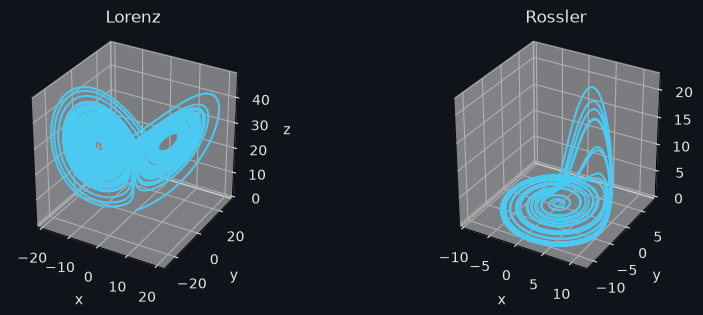

In [4]:
rossler = ts.Rossler().integrate(final_time=120.0, dt=0.02)
panel = ts.viz.plot(lorenz, rossler, layout="row").theme("dark")
panel.plot()          # a two-panel comparison, dark theme — one call

**▶ Try it.** The catalogue has **154 systems**. Swap in another 3-D attractor — `Aizawa`, `Thomas`,
`Halvorsen`, `Chen`, or `Dadras` — and re-plot. (Change the name and re-run.)

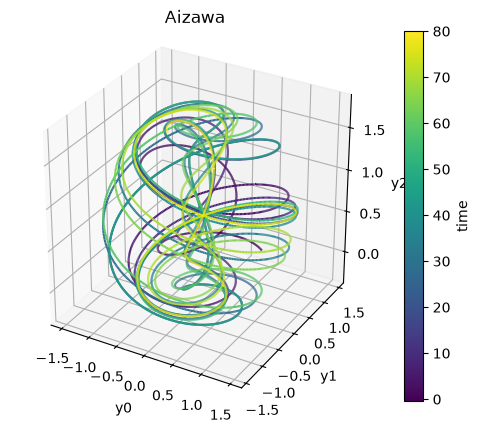

In [5]:
name = "Aizawa"
getattr(ts, name)().integrate(final_time=80.0, dt=0.005).plot(kind="phase_portrait_3d", color_by="time")

## 2 · Maps, and the road to chaos

Discrete maps use `.iterate()` and plot the same way. Here is the Hénon attractor's fractal dust:

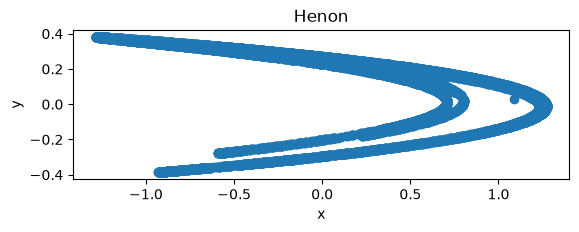

In [6]:
henon = ts.Henon().iterate(steps=8000, ic=[0.1, 0.1])
henon.plot(components=["x", "y"], kind="phase_portrait_2d")

`ts.bifurcation_diagram` sweeps a parameter and records where each orbit settles. It returns a rich
**`OrbitDiagram`** that doesn't just hold points — it *locates the cascade for you*:

first period-doubling onsets (r): [3.0022 3.4507 3.5442 3.5495]
theory says the first two are     : 3.0  and  1+√6 = 3.4495


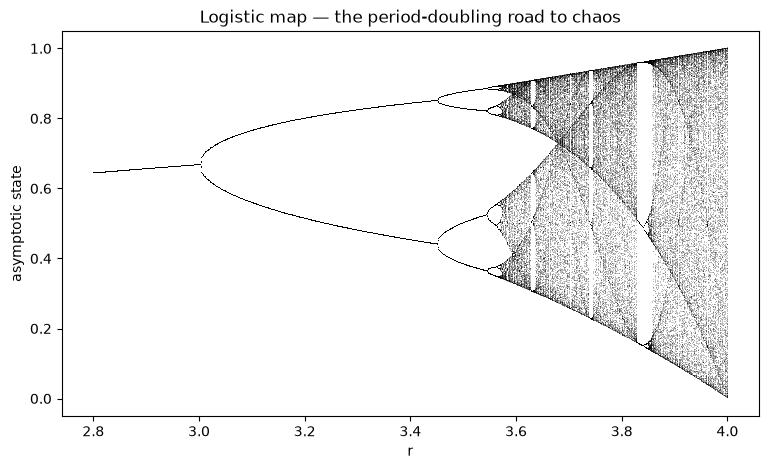

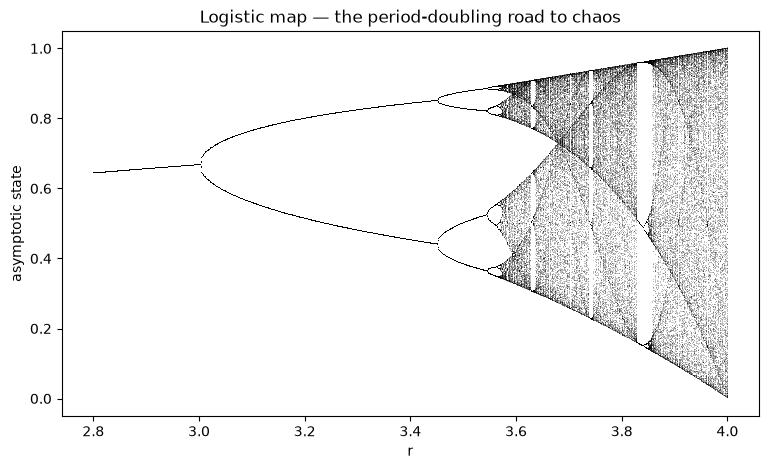

In [7]:
bif = ts.bifurcation_diagram(ts.Logistic(), "r", np.linspace(2.8, 4.0, 900), n=200, transient=500)
onsets = np.asarray(bif.bifurcation_points())     # the library finds the period-doubling loci
print("first period-doubling onsets (r):", np.round(onsets[:4], 4))
print("theory says the first two are     : 3.0  and  1+√6 =", round(1 + np.sqrt(6), 4))

# a clean render straight from the result's data
r = np.repeat(np.asarray(bif.values), np.asarray(bif.points).shape[1])
x = np.asarray(bif.points)[:, :, 0].ravel()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(r, x, ",k", alpha=0.25)
ax.set(xlabel="r", ylabel="asymptotic state", title="Logistic map — the period-doubling road to chaos")
fig

The period-doubling cascade accumulates into chaos near $r \approx 3.57$, riddled with white windows of
order — and the library pinpointed the first onsets at exactly $r=3$ and $r=1+\sqrt6$.

**▶ Try it.** Zoom the sweep to `np.linspace(3.5, 3.6, 900)` and re-run the render to see the cascade
repeat itself, self-similar, all the way down.

## 3 · Reduce a flow to a map: a 2-D Poincaré section

The most powerful move in nonlinear dynamics: slice a continuous flow with a surface and watch where it
crosses. `ts.PoincareMap` does exactly that. On the **Hénon–Heiles** system (a star orbiting in a galaxy)
the section reveals the coexistence of **order and chaos** — the hallmark of the KAM theorem.

We launch a dozen orbits at the *same energy* and overlay their crossings of the surface $x=0$.

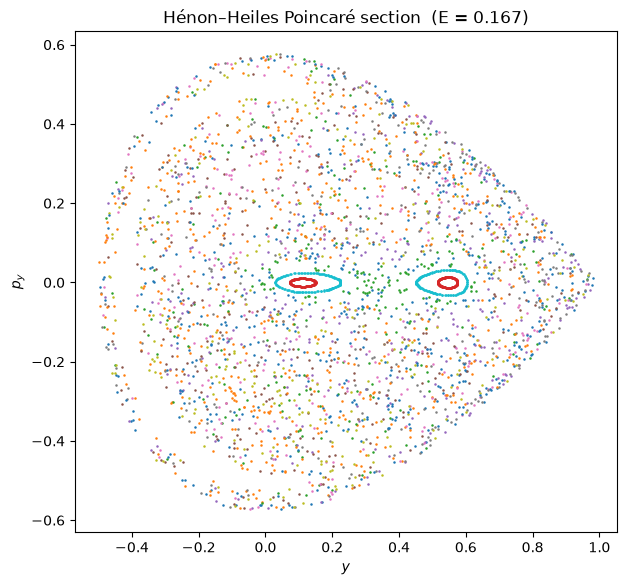

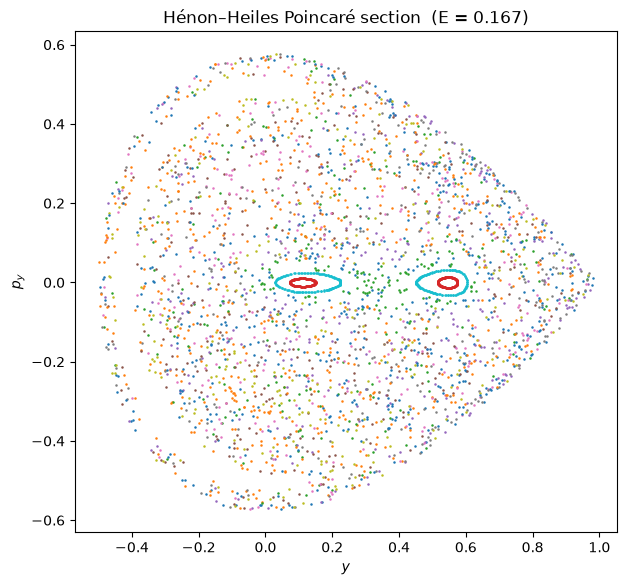

In [8]:
E = 1.0 / 6.0                                  # energy: high enough that chaos has appeared
section = ts.PoincareMap(ts.HenonHeiles(), plane=(0, 0.0, "up"))   # cross x=0 going "up" (p_x > 0)

fig, ax = plt.subplots(figsize=(7, 6.5))
for y0, py0 in [(0, 0), (0, .2), (0, -.25), (.15, 0), (-.2, 0), (0, .42),
                (0, -.42), (.3, .1), (-.3, -.1), (.45, 0), (0, .1), (-.1, .25)]:
    disc = 2 * E - py0**2 - y0**2 + 2 * y0**3 / 3     # solve the energy surface for p_x ≥ 0
    if disc <= 0:
        continue
    sec = section.trajectory(300, ic=[0.0, y0, np.sqrt(disc), py0])   # the library does the sectioning
    ax.plot(sec.y[:, 1], sec.y[:, 3], ".", ms=1.6)                    # plot (y, p_y) of each crossing
ax.set(xlabel="$y$", ylabel="$p_y$", title=f"Hénon–Heiles Poincaré section  (E = {E:.3f})")
fig

Read the picture: the **closed loops** are quasi-periodic orbits living on invariant tori (regular motion,
perfectly predictable). The **scattered haze** filling the rest is a single chaotic orbit wandering
ergodically — deterministic, but unpredictable. Both at the *same energy*, side by side.

**▶ Try it.** Raise the energy to `E = 1.0/8.0` (more regular) or push it toward `0.17` and watch the
chaotic sea drown the islands.

## 4 · Quantify the chaos

"Chaotic" should be a *number*, not an adjective. The **Lyapunov spectrum** measures the exponential
stretching rates; a positive leading exponent is the definition of chaos.

In [9]:
spectrum = ts.Lorenz().lyapunov_spectrum(final_time=200.0, dt=0.02)
print("Lorenz Lyapunov spectrum:", np.round(spectrum, 3))
print("  → leading exponent =", round(float(spectrum[0]), 3), "> 0  ⇒ chaotic")
print("  → Kaplan–Yorke dimension:", round(float(ts.kaplan_yorke_dimension(spectrum)), 3),
      "(a fractal attractor)")

# a fully model-free indicator: the 0–1 test returns K≈1 for chaos, K≈0 for order
chaotic = ts.Logistic().with_params(r=4.0).iterate(steps=3000, ic=[0.4]).y[200:, 0]
regular = ts.Logistic().with_params(r=3.5).iterate(steps=3000, ic=[0.4]).y[200:, 0]
print(f"\n0–1 test:  logistic r=4 (chaos) K = {float(ts.zero_one_test(chaotic)):.2f}"
      f"   vs   r=3.5 (period-4) K = {float(ts.zero_one_test(regular)):.2f}")

Lorenz Lyapunov spectrum: [ 9.0400e-01 -3.0000e-03 -1.4568e+01]
  → leading exponent = 0.904 > 0  ⇒ chaotic
  → Kaplan–Yorke dimension: 2.062 (a fractal attractor)



0–1 test:  logistic r=4 (chaos) K = 1.00   vs   r=3.5 (period-4) K = -0.00


**▶ Try it.** Is the Rössler system chaotic? Swap `ts.Lorenz()` for `ts.Rossler()` above (use
`final_time=400`) and check the leading exponent.

## 5 · Build your own system

The catalogue is a starting point — your research has its own equations. A system is a tiny class. Here is
the **Van der Pol** oscillator $\ddot x = \mu(1-x^2)\dot x - x$ from scratch, and it immediately inherits
*everything*: integration, plotting, Lyapunov exponents, bifurcations.

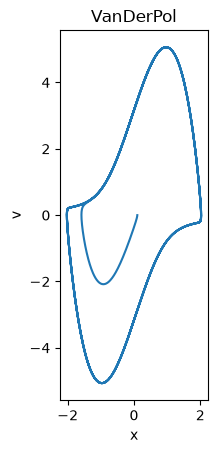

In [10]:
import symengine as se       # use symengine functions inside _equations, not numpy

class VanDerPol(ts.ContinuousSystem):
    params = {"mu": 3.0}              # sweepable parameters
    dim = 2                           # REQUIRED: state dimension
    variables = ("x", "v")            # names → traj["x"]
    default_ic = [0.1, 0.0]

    @staticmethod                     # _equations is a staticmethod with keyword-only params
    def _equations(y, t, *, mu):
        x, v = y(0), y(1)             # read state via y(0), y(1), …
        return [v, mu * (1 - x**2) * v - x]

VanDerPol().integrate(final_time=40.0, dt=0.01).plot(components=["x", "v"])   # settles onto its limit cycle

Three rules and you're done: declare `dim`, make `_equations` a `@staticmethod` with keyword-only
parameters, and use `symengine` (`se.sin`, `se.exp`, …) so the engine can compile it.

**▶ Try it.** Sweep the stiffness: change `mu` to `0.5`, `2`, or `6` and watch the relaxation oscillation
snap ever more sharply.

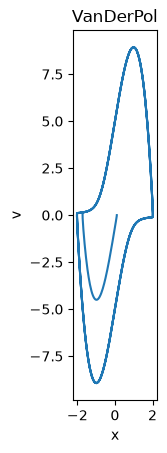

In [11]:
VanDerPol().with_params(mu=6.0).integrate(final_time=40.0, dt=0.01).plot(components=["x", "v"])

## 6 · A field that organizes itself: Gray–Scott, on camera

TSDynamics isn't only low-dimensional ODEs — it integrates **spatially-extended** systems too. The
**Gray–Scott** reaction–diffusion model turns a featureless chemical bath into fingerprints, spots, and
coral. We seed a tiny central perturbation and let it grow across a $64\times64$ periodic grid.

One flag — `kind="field", animate=True` — turns the whole space–time run into a movie. *(≈ 1 minute.)*

In [12]:
import os
from IPython.display import Video

os.makedirs("express_assets", exist_ok=True)
N = 64
gray = ts.GrayScott(params={"N": N})                 # F=0.06, k=0.062 → the "coral" regime
ic = ts.GrayScott._nucleation_ic(N, seed=0)          # the standard central-square seed

movie = gray.to_plot_spec(kind="field", animate=True, final_time=6000.0, dt=25.0, ic=ic, components="v")
movie.save("express_assets/grayscott.mp4", fps=25)
Video("express_assets/grayscott.mp4", embed=True, width=460)

From a single dot, self-replicating spots bud, collide, and freeze into a labyrinth — pattern formation
far from equilibrium, computed by the same `.integrate()` you used on Lorenz. (Swap `.save("…​.mp4")` for
`.save("…​.gif")` if you have no ffmpeg.)

## 7 · Solve a real problem: is this signal predictable?

Here's the situation you actually meet in the lab. A collaborator sends you **one scalar trace** from a
nonlinear circuit and asks two questions: *is it deterministic (worth modelling) or just noise, and how
far ahead can we predict it?* You have no equations — only the data. The analysis toolkit answers both.

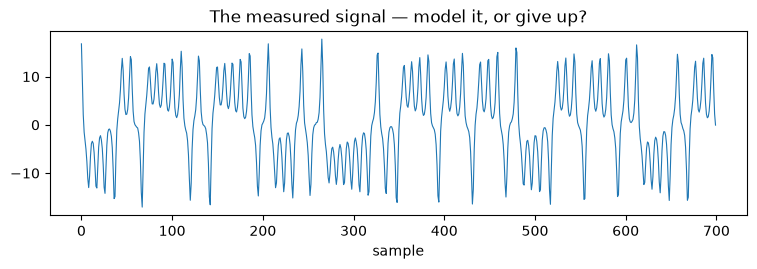

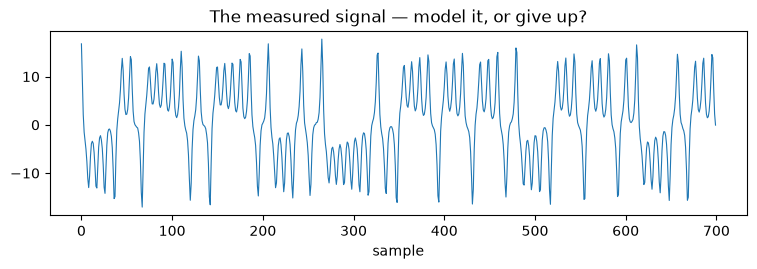

In [13]:
# One measured channel (we built it from a chaotic system + sensor noise; play along — you only get this).
rng = np.random.default_rng(0)
_src = ts.Lorenz().integrate(final_time=400.0, dt=0.01)
signal = _src.y[_src.t > 20.0, 0][::8]                           # one coordinate, subsampled to dt=0.08 s
signal = signal + 0.01 * np.std(signal) * rng.standard_normal(signal.shape)
DT = 0.08

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(signal[:700], lw=0.8); ax.set(title="The measured signal — model it, or give up?", xlabel="sample")
fig

**Step 1 — reconstruct the attractor.** Takens' theorem: a single channel, delayed against itself,
redraws the hidden dynamics. The library picks a good delay (via mutual information) and builds it.

optimal delay τ = 2 samples,  embedding dimension m = 4


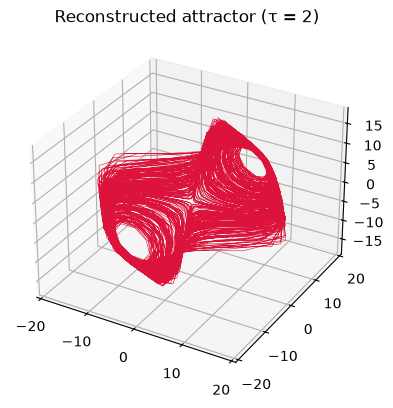

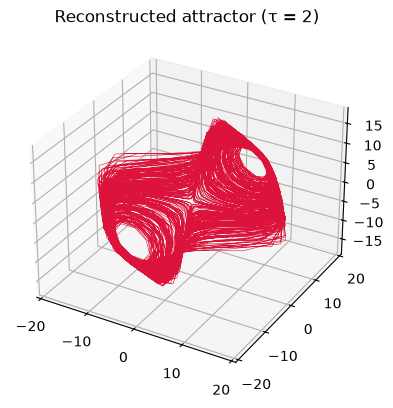

In [14]:
from tsdynamics.analysis.embedding import optimal_delay, embedding_dimension, embed

tau = int(optimal_delay(signal).value)
m = embedding_dimension(signal, delay=tau).dimension        # Cao's method
print(f"optimal delay τ = {tau} samples,  embedding dimension m = {m}")

emb = np.asarray(embed(signal, dimension=4, delay=tau))
fig = plt.figure(figsize=(5.4, 4.6)); ax = fig.add_subplot(111, projection="3d")
ax.plot(emb[:, 0], emb[:, 1], emb[:, 2], lw=0.4, color="crimson")
ax.set_title(f"Reconstructed attractor (τ = {tau})"); fig

Not a fuzzball — a structured object. **Step 2 — measure its fractal dimension.** A low value means few
active degrees of freedom. The result object plots its own scaling fit.

correlation dimension D₂ ≈ 2.07  → low-dimensional (≈ 2 active d.o.f.)


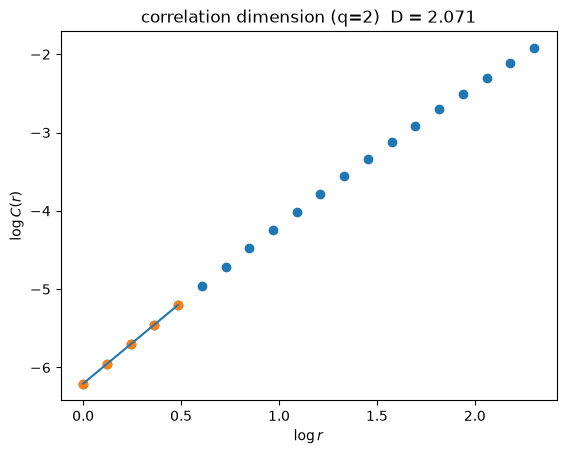

In [15]:
D2 = ts.correlation_dimension(emb, radii=np.logspace(0.0, 1.0, 20))
print("correlation dimension D₂ ≈", round(float(D2.value), 2), " → low-dimensional (≈ 2 active d.o.f.)")
D2.plot()

**Step 3 — how far ahead can we predict?** `lyapunov_from_data` (Kantz) measures the exponential growth
of forecast error straight from the series. Its reciprocal is the **predictability horizon**.

largest Lyapunov exponent λ ≈ 1.068 /s
predictability horizon ≈ 1/λ ≈ 0.9 s — forecasts beyond this are worthless


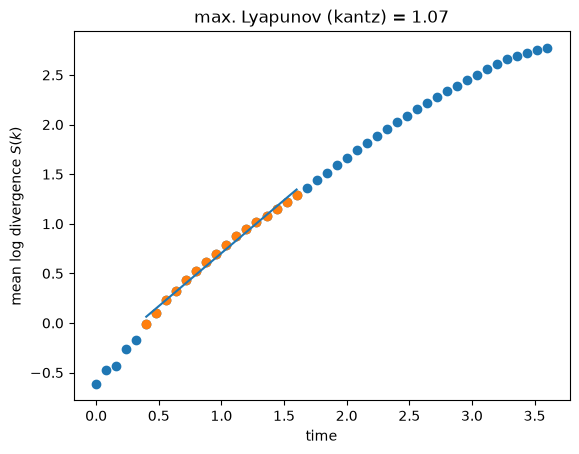

In [16]:
lyap = ts.lyapunov_from_data(signal, dt=DT, dimension=5, delay=tau, k_max=45, fit=(5, 20))
print(f"largest Lyapunov exponent λ ≈ {lyap.value:.3f} /s")
print(f"predictability horizon ≈ 1/λ ≈ {1/lyap.value:.1f} s — forecasts beyond this are worthless")
lyap.plot()          # the stretching curve S(k); the fitted region gives λ

**Step 4 — put "it's just noise" on trial.** A **surrogate test** manufactures signals with the *same
power spectrum* but no nonlinear structure, and checks whether the data is genuinely more predictable.

In [17]:
verdict = ts.surrogate_test(signal[:2500], statistic="prediction_error", method="iaaft", n=39, seed=1)
print(verdict.summary())

# control: the identical test on stationary colored (AR-1) noise, which it should NOT reject
ar = np.zeros(2500); eps = rng.standard_normal(2500)
for i in range(1, 2500):
    ar[i] = 0.9 * ar[i - 1] + eps[i]
ctrl = ts.surrogate_test(ar, statistic="prediction_error", method="iaaft", n=39, seed=1).to_dict()
print(f"\ncontrol (AR-1 noise): rejected = {ctrl['rejected']}  → correctly cleared")

SurrogateTest
  data_statistic = 0.0442796
  p_value = 0.025
  z_score = -76.0754
  rejected = True
  statistic = 'prediction_error'
  method = 'iaaft'
  n_surrogates = 39
  tail = 'less'
  alpha = 0.05



control (AR-1 noise): rejected = False  → correctly cleared


**The verdict.** The reconstruction has structure, the dimension is low (~2), the forecast error grows at
a definite rate, and the surrogate null is decisively rejected while genuine noise is cleared. So: *this is
low-dimensional deterministic chaos.* Model it with a handful of variables — but don't bother forecasting
past its Lyapunov horizon. That is a real, defensible answer, extracted from one wiggly line.

---
## That's the tour

In one notebook you have, using the library idiomatically throughout:

- **integrated** flows and maps and let the `viz` layer **compose, theme, and save** the figures,
- reduced a flow to a **2-D Poincaré map** showing order and chaos coexisting,
- **quantified** chaos with a Lyapunov spectrum, a fractal dimension, and the 0–1 test,
- **built your own system** in six lines,
- watched a **reaction–diffusion field** self-organize on camera, and
- **solved a real problem** — is this signal predictable? — end to end from a single measured channel.

**Go deeper.** The full multi-notebook workshop — custom DDE/SDE models, stroboscopic maps, fixed points
& stability, basins of attraction, tipping points, and a power-grid capstone — lives on the
[`main` branch](https://github.com/El3ssar/tsdynamics-workshop/tree/main). Docs:
**https://el3ssar.github.io/TSDynamics/**.

Happy hunting. 🦋